# Stroke Mobility IMU Phone-Lab Validation

This notebook validates smartphone-derived IMU features against multi-sensor laboratory IMU summaries at the patient level. It uses QC scores directly, applies activity-specific filtering, summarizes phone rows per patient using median/IQR as primary statistics, and then compares patient-level phone summaries with lab summaries.

## Imports

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Paths, Feature Groups, and QC Rules

Set `INCLUDE_COMBINED_PHONE_FILE = True` only if you want to include `features_dataset.csv`; by default the notebook reads `features_dataset_<patient_id>.csv` files to avoid duplicates.

In [2]:
ROOT = Path.cwd()
PHONE_GLOB = "features_dataset_*.csv"
INCLUDE_COMBINED_PHONE_FILE = False  # keep False to avoid duplicates when per-patient CSVs exist
COMBINED_PHONE_FILE = ROOT / "features_dataset.csv"
LAB_DIR = ROOT / "Sensors_Visualizers"
OUTPUT_DIR = ROOT / "validation_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUBJECT_MAPPING_CANDIDATES = [
    ROOT / "subjects.json",
    LAB_DIR / "subjects.json",
    ROOT / "config" / "subjects.json",
]

GOOD_ONLY = "good_only"
GOOD_PLUS_QUESTIONABLE = "good_plus_questionable"

WALKING_PHONE_FEATURES = [
    "walk_duration", "step_count", "cadence", "walking_speed", "mean_step_time", "step_time_std", "step_time_cv",
    "step_regularity", "stride_regularity", "walk_acc_mag_mean", "walk_acc_mag_std", "walk_acc_mag_rms",
    "walk_gyro_mag_std", "walk_dominant_frequency", "walk_spectral_entropy", "walk_jerk_mean", "walk_jerk_std",
    "approximate_entropy", "sample_entropy", "symbolic_entropy", "permutation_entropy",
    "rosenstein_lyapunov_exponent", "wolf_lyapunov_exponent", "rqa_REC", "rqa_DET", "rqa_LAM",
    "rqa_MeanL", "rqa_MaxL", "rqa_EntrL", "rqa_EntrV", "rqa_EntrW",
]
LEFT_TURN_PHONE_FEATURES = [
    "left_turn_duration", "left_turn_mean_angular_velocity", "left_turn_peak_angular_velocity",
    "left_turn_ang_vel_std", "left_turn_step_count", "left_turn_pause_time", "left_turn_jerk_std", "left_turn_entropy",
]
RIGHT_TURN_PHONE_FEATURES = [
    "right_turn_duration", "right_turn_mean_angular_velocity", "right_turn_peak_angular_velocity",
    "right_turn_ang_vel_std", "right_turn_step_count", "right_turn_pause_time", "right_turn_jerk_std", "right_turn_entropy",
]
TURN_COMPARISON_FEATURES = [
    "turn_duration_difference", "turn_velocity_difference", "turn_pause_difference",
    "abs_turn_duration_difference", "abs_turn_velocity_difference", "abs_turn_pause_difference",
    "turn_left_right_xcorr_symmetry_score", "turn_left_right_xcorr_peak_correlation",
]
SIT_TO_STAND_PHONE_FEATURES = [
    "sit_to_stand_duration", "sit_to_stand_time_to_peak_acc", "sit_to_stand_peak_acc",
    "sit_to_stand_flexion_peak", "sit_to_stand_extension_peak", "sit_to_stand_peak_gyro",
    "sit_to_stand_acc_rms", "sit_to_stand_jerk_mean", "sit_to_stand_jerk_std",
    "sit_to_stand_peak_count", "sit_to_stand_entropy",
]
STAND_TO_SIT_PHONE_FEATURES = [
    "stand_to_sit_duration", "stand_to_sit_time_to_peak_acc", "stand_to_sit_peak_acc",
    "stand_to_sit_flexion_peak", "stand_to_sit_extension_peak", "stand_to_sit_peak_gyro",
    "stand_to_sit_acc_rms", "stand_to_sit_jerk_mean", "stand_to_sit_jerk_std",
    "stand_to_sit_peak_count", "stand_to_sit_entropy",
]
SIT_STAND_COMPARISON_FEATURES = [
    "sitstand_standsit_xcorr_symmetry_score", "sitstand_standsit_xcorr_peak_correlation",
]

PHONE_FEATURE_GROUPS = {
    "walk": {"qc_col": "walk_qc_score", "good_score": 5, "usable_min": 3, "features": WALKING_PHONE_FEATURES},
    "left_turn": {"qc_col": "left_turn_qc_score", "good_score": 5, "usable_min": 3, "features": LEFT_TURN_PHONE_FEATURES},
    "right_turn": {"qc_col": "right_turn_qc_score", "good_score": 5, "usable_min": 3, "features": RIGHT_TURN_PHONE_FEATURES},
    "turn_comparison": {"qc_cols": ["left_turn_qc_score", "right_turn_qc_score"], "good_score": 5, "usable_min": 3, "features": TURN_COMPARISON_FEATURES},
    "sit_to_stand": {"qc_col": "sit_to_stand_qc_score", "good_score": 4, "usable_min": 3, "features": SIT_TO_STAND_PHONE_FEATURES},
    "stand_to_sit": {"qc_col": "stand_to_sit_qc_score", "good_score": 4, "usable_min": 3, "features": STAND_TO_SIT_PHONE_FEATURES},
    "sitstand_comparison": {"qc_cols": ["sit_to_stand_qc_score", "stand_to_sit_qc_score"], "good_score": 4, "usable_min": 3, "features": SIT_STAND_COMPARISON_FEATURES},
}

QC_ACTIVITIES = {
    "walk": {"qc_col": "walk_qc_score", "good_score": 5, "questionable": [3, 4]},
    "left_turn": {"qc_col": "left_turn_qc_score", "good_score": 5, "questionable": [3, 4]},
    "right_turn": {"qc_col": "right_turn_qc_score", "good_score": 5, "questionable": [3, 4]},
    "sit_to_stand": {"qc_col": "sit_to_stand_qc_score", "good_score": 4, "questionable": [3]},
    "stand_to_sit": {"qc_col": "stand_to_sit_qc_score", "good_score": 4, "questionable": [3]},
}

## Reusable Analysis Functions

These functions load phone files, load lab files, map lab subject IDs to phone patient IDs, create QC yield summaries, summarize phone/lab data by patient, merge phone and lab summaries, compute validation metrics, rank features, and handle missing columns gracefully.

In [3]:
def normalize_patient_id(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if not text:
        return np.nan
    if text.lower().startswith("patient_"):
        suffix = text.split("_", 1)[1]
        try:
            return f"patient_{int(float(suffix))}"
        except ValueError:
            return text
    try:
        return f"patient_{int(float(text))}"
    except ValueError:
        return text


def normalize_subject_id(value):
    if pd.isna(value):
        return np.nan
    return str(value).strip()


def load_phone_files(phone_glob=PHONE_GLOB, include_combined=INCLUDE_COMBINED_PHONE_FILE):
    files = sorted(ROOT.glob(phone_glob))
    if include_combined and COMBINED_PHONE_FILE.exists():
        files = [COMBINED_PHONE_FILE] + files
    files = [p for p in files if p.name != COMBINED_PHONE_FILE.name or include_combined]
    frames = []
    for path in files:
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            print(f"[WARN] Could not read phone file {path}: {exc}")
            continue
        df["source_file"] = path.name
        if "patient_id" not in df.columns:
            df["patient_id"] = path.stem.replace("features_dataset_", "")
        df["patient_id"] = df["patient_id"].map(normalize_patient_id)
        if "date" in df.columns:
            df["date"] = df["date"].astype(str)
        frames.append(df)
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()


def load_subject_mapping(candidates=SUBJECT_MAPPING_CANDIDATES):
    for path in candidates:
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                raw = json.load(f)
            mapping = {normalize_subject_id(k): normalize_patient_id(v) for k, v in raw.items()}
            print(f"Loaded subject mapping from {path}")
            return mapping
    print("[WARN] subjects.json was not found. Lab rows will not match phone rows until mapping is added.")
    return {}


def make_patient_to_subject_mapping(subject_mapping):
    reverse = {}
    for subject_id, patient_id in subject_mapping.items():
        reverse.setdefault(patient_id, subject_id)
    return reverse


def add_subject_ids(df, patient_to_subject):
    if df is None or df.empty or "patient_id" not in df.columns:
        return df
    df = df.copy()
    subject_values = df["patient_id"].map(patient_to_subject)
    if "subject_id" in df.columns:
        df["subject_id"] = df["subject_id"].fillna(subject_values)
    else:
        insert_at = df.columns.get_loc("patient_id")
        df.insert(insert_at, "subject_id", subject_values)
    return df


def load_lab_files(lab_dir=LAB_DIR):
    lab_files = {
        "outside": lab_dir / "outside_results.csv",
        "treadmill": lab_dir / "treadmill_results.csv",
        "turn_left": lab_dir / "turn_left_results.csv",
        "turn_right": lab_dir / "turn_right_results.csv",
        "turn_p": lab_dir / "turn_p_results.csv",
        "sit_to_stand": lab_dir / "sit_to_stand_results.csv",
        "stand_to_sit": lab_dir / "stand_to_sit_results.csv",
    }
    lab = {}
    for name, path in lab_files.items():
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df["lab_activity"] = name
        if "subject_id" in df.columns:
            df["subject_id"] = df["subject_id"].map(normalize_subject_id)
        lab[name] = df
    return lab


def map_subjects_to_patient_ids(lab_data, subject_mapping):
    mapped = {}
    for activity, df in lab_data.items():
        df = df.copy()
        df["patient_id"] = df["subject_id"].map(subject_mapping) if "subject_id" in df.columns else np.nan
        mapped[activity] = df
    return mapped


def qc_yield_summary(phone):
    records = []
    if phone.empty:
        return pd.DataFrame(records)
    for patient_id, g in phone.groupby("patient_id", dropna=False):
        total = len(g)
        for activity, cfg in QC_ACTIVITIES.items():
            qc_col = cfg["qc_col"]
            if qc_col not in g.columns:
                good = questionable = 0
                bad = total
            else:
                scores = pd.to_numeric(g[qc_col], errors="coerce")
                good = int((scores == cfg["good_score"]).sum())
                questionable = int(scores.isin(cfg["questionable"]).sum())
                bad = int((~((scores == cfg["good_score"]) | scores.isin(cfg["questionable"]))).sum())
            usable = good + questionable
            records.append({
                "patient_id": patient_id, "activity": activity, "total_rows": total,
                "good_rows": good, "questionable_rows": questionable, "bad_rows": bad,
                "percent_good": 100.0 * good / total if total else np.nan,
                "percent_usable": 100.0 * usable / total if total else np.nan,
            })
    return pd.DataFrame(records)


def _qc_mask(df, cfg, mode):
    qc_cols = [cfg["qc_col"]] if "qc_col" in cfg else cfg.get("qc_cols", [])
    if not qc_cols or any(c not in df.columns for c in qc_cols):
        return pd.Series(False, index=df.index)
    scores = df[qc_cols].apply(pd.to_numeric, errors="coerce")
    if mode == GOOD_ONLY:
        return (scores == cfg["good_score"]).all(axis=1)
    if mode == GOOD_PLUS_QUESTIONABLE:
        return (scores >= cfg["usable_min"]).all(axis=1)
    raise ValueError(f"Unknown QC mode: {mode}")


def _summarize_values(values):
    values = pd.to_numeric(values, errors="coerce").dropna()
    if values.empty:
        return {"median": np.nan, "iqr_low": np.nan, "iqr_high": np.nan, "mean": np.nan, "std": np.nan, "valid_n": 0}
    return {
        "median": float(values.median()),
        "iqr_low": float(values.quantile(0.25)),
        "iqr_high": float(values.quantile(0.75)),
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)) if len(values) > 1 else 0.0,
        "valid_n": int(values.count()),
    }


def summarize_phone_by_patient(phone, mode=GOOD_ONLY):
    records = []
    if phone.empty:
        return pd.DataFrame()
    for patient_id, g in phone.groupby("patient_id", dropna=False):
        record = {"patient_id": patient_id, "phone_total_rows": len(g)}
        for group_name, cfg in PHONE_FEATURE_GROUPS.items():
            mask = _qc_mask(g, cfg, mode)
            filtered = g.loc[mask]
            record[f"{group_name}_qc_valid_rows"] = int(mask.sum())
            record[f"{group_name}_qc_valid_percent"] = 100.0 * float(mask.sum()) / len(g) if len(g) else np.nan
            for feature in cfg["features"]:
                if feature not in g.columns:
                    continue
                stats_row = _summarize_values(filtered[feature])
                for stat_name, stat_value in stats_row.items():
                    record[f"{feature}_{stat_name}"] = stat_value
                record[f"{feature}_valid_percent"] = 100.0 * stats_row["valid_n"] / len(g) if len(g) else np.nan
        records.append(record)
    summary = pd.DataFrame(records).sort_values("patient_id").reset_index(drop=True)
    numeric_cols = summary.select_dtypes(include=[np.number]).columns
    summary[numeric_cols] = summary[numeric_cols].round(3)
    return summary


WALK_TIMING_SENSORS = ["right", "left", "sacrum", "trunk"]
WAIST_SENSORS = ["sacrum", "trunk", "right", "left"]
TURN_SENSORS = ["sacrum", "trunk", "right", "left"]
TRANSITION_SENSORS = ["sacrum", "trunk", "right", "left"]

LAB_COMPARISON_SPECS = [
    {"feature": "cadence", "lab_activities": ["outside", "treadmill"], "metric": "cadence", "sensors": WALK_TIMING_SENSORS, "category": "walk"},
    {"feature": "mean_step_time", "lab_activities": ["outside", "treadmill"], "metric": "mean_step_time", "sensors": WALK_TIMING_SENSORS, "category": "walk"},
    {"feature": "step_count", "lab_activities": ["outside", "treadmill"], "metric": "step_count", "sensors": WALK_TIMING_SENSORS, "category": "walk_caution"},
    {"feature": "walk_duration", "lab_activities": ["outside", "treadmill"], "metric": "duration", "sensors": WAIST_SENSORS, "category": "walk_caution"},
    {"feature": "left_turn_duration", "lab_activities": ["turn_left"], "metric": "turn_duration", "sensors": TURN_SENSORS, "category": "turn"},
    {"feature": "left_turn_step_count", "lab_activities": ["turn_left"], "metric": "turn_step_count", "sensors": TURN_SENSORS, "category": "turn_caution"},
    {"feature": "left_turn_peak_angular_velocity", "lab_activities": ["turn_left"], "metric": "peak_angular_velocity", "sensors": TURN_SENSORS, "category": "turn"},
    {"feature": "left_turn_mean_angular_velocity", "lab_activities": ["turn_left"], "metric": "mean_angular_velocity", "sensors": TURN_SENSORS, "category": "turn"},
    {"feature": "right_turn_duration", "lab_activities": ["turn_right"], "metric": "turn_duration", "sensors": TURN_SENSORS, "category": "turn"},
    {"feature": "right_turn_step_count", "lab_activities": ["turn_right"], "metric": "turn_step_count", "sensors": TURN_SENSORS, "category": "turn_caution"},
    {"feature": "right_turn_peak_angular_velocity", "lab_activities": ["turn_right"], "metric": "peak_angular_velocity", "sensors": TURN_SENSORS, "category": "turn"},
    {"feature": "right_turn_mean_angular_velocity", "lab_activities": ["turn_right"], "metric": "mean_angular_velocity", "sensors": TURN_SENSORS, "category": "turn"},
    {"feature": "sit_to_stand_duration", "lab_activities": ["sit_to_stand"], "metric": "duration", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "sit_to_stand_time_to_peak_acc", "lab_activities": ["sit_to_stand"], "metric": "time_to_peak_acc", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "sit_to_stand_peak_acc", "lab_activities": ["sit_to_stand"], "metric": "peak_acc", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "sit_to_stand_peak_gyro", "lab_activities": ["sit_to_stand"], "metric": "peak_gyro", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "sit_to_stand_flexion_peak", "lab_activities": ["sit_to_stand"], "metric": "flexion_peak", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "sit_to_stand_extension_peak", "lab_activities": ["sit_to_stand"], "metric": "extension", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "stand_to_sit_duration", "lab_activities": ["stand_to_sit"], "metric": "duration", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "stand_to_sit_time_to_peak_acc", "lab_activities": ["stand_to_sit"], "metric": "time_to_peak_acc", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "stand_to_sit_peak_acc", "lab_activities": ["stand_to_sit"], "metric": "peak_acc", "sensors": TRANSITION_SENSORS, "category": "transition"},
    {"feature": "stand_to_sit_peak_gyro", "lab_activities": ["stand_to_sit"], "metric": "peak_gyro", "sensors": TRANSITION_SENSORS, "category": "transition"},
]


def _first_sensor_value(row, metric, sensors):
    for sensor in sensors:
        col = f"{sensor}_{metric}"
        if col in row.index:
            value = pd.to_numeric(pd.Series([row[col]]), errors="coerce").iloc[0]
            if pd.notna(value):
                return float(value), sensor, col
    return np.nan, None, None


def summarize_lab_by_patient(lab_data):
    long_records = []
    for spec in LAB_COMPARISON_SPECS:
        for activity in spec["lab_activities"]:
            df = lab_data.get(activity)
            if df is None or df.empty:
                continue
            for _, row in df.iterrows():
                patient_id = row.get("patient_id")
                if pd.isna(patient_id):
                    continue
                value, sensor, col = _first_sensor_value(row, spec["metric"], spec["sensors"])
                if not np.isfinite(value):
                    continue
                long_records.append({
                    "patient_id": patient_id, "subject_id": row.get("subject_id"), "visit": row.get("visit"),
                    "lab_activity": activity, "phone_feature": spec["feature"], "lab_metric": spec["metric"],
                    "lab_value": value, "lab_sensor": sensor, "lab_column": col, "comparison_category": spec["category"],
                })
    lab_long = pd.DataFrame(long_records)
    lab_summary_columns = [
        "patient_id", "phone_feature", "lab_median", "lab_mean", "lab_std", "lab_valid_n",
        "lab_sensor_used", "lab_activity_used", "comparison_category",
    ]
    if lab_long.empty:
        lab_summary_long = pd.DataFrame(columns=lab_summary_columns)
        lab_summary_long.to_csv(OUTPUT_DIR / "lab_patient_summary_long.csv", index=False, float_format="%.3f")
        pd.DataFrame(columns=["patient_id"]).to_csv(OUTPUT_DIR / "lab_patient_summary.csv", index=False, float_format="%.3f")
        return lab_summary_long, lab_long
    summary_records = []
    for (patient_id, feature), g in lab_long.groupby(["patient_id", "phone_feature"]):
        values = pd.to_numeric(g["lab_value"], errors="coerce").dropna()
        if values.empty:
            continue
        summary_records.append({
            "patient_id": patient_id,
            "phone_feature": feature,
            "lab_median": float(values.median()),
            "lab_mean": float(values.mean()),
            "lab_std": float(values.std(ddof=1)) if len(values) > 1 else 0.0,
            "lab_valid_n": int(values.count()),
            "lab_sensor_used": ",".join(sorted(set(g["lab_sensor"].dropna().astype(str)))),
            "lab_activity_used": ",".join(sorted(set(g["lab_activity"].dropna().astype(str)))),
            "comparison_category": g["comparison_category"].iloc[0],
        })
    lab_summary_long = pd.DataFrame(summary_records).sort_values(["patient_id", "phone_feature"]).reset_index(drop=True)
    numeric_cols = lab_summary_long.select_dtypes(include=[np.number]).columns
    lab_summary_long[numeric_cols] = lab_summary_long[numeric_cols].round(3)
    lab_summary_long.to_csv(OUTPUT_DIR / "lab_patient_summary_long.csv", index=False, float_format="%.3f")
    lab_wide = lab_summary_long.pivot(index="patient_id", columns="phone_feature", values="lab_median")
    lab_wide.columns = [f"{c}_lab_median" for c in lab_wide.columns]
    lab_wide = lab_wide.reset_index()
    lab_wide.to_csv(OUTPUT_DIR / "lab_patient_summary.csv", index=False, float_format="%.3f")
    return lab_summary_long, lab_long


def merge_phone_lab(phone_summary, lab_summary_long):
    comparison_columns = [
        "patient_id", "feature", "comparison_category", "phone_median", "phone_iqr_low", "phone_iqr_high",
        "phone_mean", "phone_std", "phone_valid_n", "lab_value", "lab_median", "lab_sensor_used",
        "lab_activity_used", "lab_valid_n", "error", "absolute_error", "percent_error",
    ]
    if phone_summary.empty or lab_summary_long.empty:
        return pd.DataFrame(columns=comparison_columns)
    records = []
    phone_by_patient = phone_summary.set_index("patient_id")
    for _, lab_row in lab_summary_long.iterrows():
        patient_id = lab_row["patient_id"]
        feature = lab_row["phone_feature"]
        if patient_id not in phone_by_patient.index:
            continue
        phone_row = phone_by_patient.loc[patient_id]
        median_col = f"{feature}_median"
        if median_col not in phone_row.index:
            continue
        phone_median = pd.to_numeric(pd.Series([phone_row.get(median_col)]), errors="coerce").iloc[0]
        lab_value = pd.to_numeric(pd.Series([lab_row.get("lab_median")]), errors="coerce").iloc[0]
        if pd.isna(phone_median) or pd.isna(lab_value):
            continue
        error = float(phone_median - lab_value)
        abs_error = abs(error)
        percent_error = 100.0 * abs_error / abs(lab_value) if lab_value != 0 else np.nan
        records.append({
            "patient_id": patient_id, "feature": feature, "comparison_category": lab_row.get("comparison_category"),
            "phone_median": float(phone_median), "phone_iqr_low": phone_row.get(f"{feature}_iqr_low", np.nan),
            "phone_iqr_high": phone_row.get(f"{feature}_iqr_high", np.nan), "phone_mean": phone_row.get(f"{feature}_mean", np.nan),
            "phone_std": phone_row.get(f"{feature}_std", np.nan), "phone_valid_n": phone_row.get(f"{feature}_valid_n", np.nan),
            "lab_value": float(lab_value), "lab_median": float(lab_value), "lab_sensor_used": lab_row.get("lab_sensor_used"),
            "lab_activity_used": lab_row.get("lab_activity_used"), "lab_valid_n": lab_row.get("lab_valid_n", np.nan),
            "error": error, "absolute_error": abs_error, "percent_error": percent_error,
        })
    comparison = pd.DataFrame(records, columns=comparison_columns)
    if not comparison.empty:
        numeric_cols = comparison.select_dtypes(include=[np.number]).columns
        comparison[numeric_cols] = comparison[numeric_cols].round(3)
    return comparison


def rmse(x):
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.nanmean(x ** 2))) if len(x) else np.nan


def icc_absolute_agreement(phone, lab):
    data = np.column_stack([np.asarray(phone, dtype=float), np.asarray(lab, dtype=float)])
    data = data[np.isfinite(data).all(axis=1)]
    if data.ndim != 2 or data.shape[0] < 5 or data.shape[1] != 2:
        return np.nan
    n, k = data.shape
    mean_subject = data.mean(axis=1, keepdims=True)
    mean_rater = data.mean(axis=0, keepdims=True)
    grand = data.mean()
    ss_subject = k * np.sum((mean_subject - grand) ** 2)
    ss_rater = n * np.sum((mean_rater - grand) ** 2)
    ss_error = np.sum((data - mean_subject - mean_rater + grand) ** 2)
    ms_subject = ss_subject / (n - 1)
    ms_rater = ss_rater / (k - 1)
    ms_error = ss_error / ((n - 1) * (k - 1))
    denom = ms_subject + (k - 1) * ms_error + k * (ms_rater - ms_error) / n
    return float((ms_subject - ms_error) / denom) if denom != 0 else np.nan


def compute_comparison_metrics(comparison):
    metric_columns = [
        "feature", "comparison_category", "matched_n", "MAE", "RMSE", "median_absolute_error",
        "median_percent_error", "spearman_correlation", "pearson_correlation", "ICC_absolute_agreement",
        "bland_altman_bias", "bland_altman_loa_low", "bland_altman_loa_high",
    ]
    records = []
    if comparison.empty:
        return pd.DataFrame(columns=metric_columns)
    for feature, g in comparison.groupby("feature"):
        g = g.dropna(subset=["phone_median", "lab_value"])
        matched_n = len(g)
        if matched_n == 0:
            continue
        errors = g["error"].astype(float)
        abs_errors = g["absolute_error"].astype(float)
        pct_errors = g["percent_error"].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
        phone = g["phone_median"].astype(float)
        lab = g["lab_value"].astype(float)
        pearson = spearman = np.nan
        if matched_n >= 3 and phone.nunique() > 1 and lab.nunique() > 1:
            try:
                pearson = float(stats.pearsonr(phone, lab).statistic)
            except Exception:
                pass
            try:
                spearman = float(stats.spearmanr(phone, lab).statistic)
            except Exception:
                pass
        diff = phone - lab
        bias = float(diff.mean())
        loa_sd = float(diff.std(ddof=1)) if matched_n > 1 else np.nan
        records.append({
            "feature": feature,
            "comparison_category": g["comparison_category"].dropna().iloc[0] if g["comparison_category"].notna().any() else "unknown",
            "matched_n": matched_n,
            "MAE": float(abs_errors.mean()),
            "RMSE": rmse(errors),
            "median_absolute_error": float(abs_errors.median()),
            "median_percent_error": float(pct_errors.median()) if len(pct_errors) else np.nan,
            "spearman_correlation": spearman,
            "pearson_correlation": pearson,
            "ICC_absolute_agreement": icc_absolute_agreement(phone, lab),
            "bland_altman_bias": bias,
            "bland_altman_loa_low": bias - 1.96 * loa_sd if np.isfinite(loa_sd) else np.nan,
            "bland_altman_loa_high": bias + 1.96 * loa_sd if np.isfinite(loa_sd) else np.nan,
        })
    metrics = pd.DataFrame(records, columns=metric_columns).sort_values(["matched_n", "median_percent_error"], ascending=[False, True]).reset_index(drop=True)
    numeric_cols = metrics.select_dtypes(include=[np.number]).columns
    metrics[numeric_cols] = metrics[numeric_cols].round(3)
    return metrics


def rank_features(metrics):
    if metrics.empty:
        ranked = metrics.copy()
        if "validation_strength" not in ranked.columns:
            ranked["validation_strength"] = pd.Series(dtype="object")
        return ranked
    exploratory_terms = ["entropy", "lyapunov", "rqa", "jerk", "xcorr", "spectral"]
    clinically_interpretable = {
        "cadence", "mean_step_time", "step_time_cv", "step_regularity", "stride_regularity",
        "left_turn_duration", "right_turn_duration", "left_turn_peak_angular_velocity", "right_turn_peak_angular_velocity",
        "left_turn_mean_angular_velocity", "right_turn_mean_angular_velocity",
        "sit_to_stand_duration", "sit_to_stand_time_to_peak_acc", "sit_to_stand_peak_acc", "sit_to_stand_peak_gyro",
    }
    labels = []
    for _, row in metrics.iterrows():
        feature = row["feature"]
        matched_n = row.get("matched_n", 0)
        med_pct = row.get("median_percent_error", np.nan)
        rho = row.get("spearman_correlation", np.nan)
        is_exploratory = any(term in feature.lower() for term in exploratory_terms)
        low_error = np.isfinite(med_pct) and med_pct <= 20
        moderate_error = np.isfinite(med_pct) and med_pct <= 35
        good_corr = np.isfinite(rho) and abs(rho) >= 0.60
        moderate_corr = np.isfinite(rho) and abs(rho) >= 0.40
        if is_exploratory:
            label = "exploratory"
        elif matched_n >= 5 and low_error and good_corr and feature in clinically_interpretable:
            label = "strong"
        elif matched_n >= 3 and (moderate_error or moderate_corr):
            label = "moderate"
        else:
            label = "weak"
        labels.append(label)
    ranked = metrics.copy()
    ranked["validation_strength"] = labels
    order = {"strong": 0, "moderate": 1, "weak": 2, "exploratory": 3}
    ranked["rank_order"] = ranked["validation_strength"].map(order).fillna(9)
    ranked = ranked.sort_values(["rank_order", "matched_n", "median_percent_error"], ascending=[True, False, True]).drop(columns=["rank_order"])
    return ranked.reset_index(drop=True)

## Run Patient-Level Analysis

This cell writes the requested CSV outputs to `validation_outputs/`.

In [4]:
phone_df = load_phone_files()
subject_mapping = load_subject_mapping()
patient_to_subject = make_patient_to_subject_mapping(subject_mapping)
phone_df = add_subject_ids(phone_df, patient_to_subject)
lab_data = map_subjects_to_patient_ids(load_lab_files(), subject_mapping)

print("Phone rows:", len(phone_df), "subjects:", phone_df["subject_id"].nunique() if "subject_id" in phone_df.columns and not phone_df.empty else 0)
print("Lab files:", {k: len(v) for k, v in lab_data.items()})

qc_yield = add_subject_ids(qc_yield_summary(phone_df), patient_to_subject)
qc_yield.to_csv(OUTPUT_DIR / "qc_yield_summary.csv", index=False, float_format="%.3f")

phone_summary_good = add_subject_ids(summarize_phone_by_patient(phone_df, GOOD_ONLY), patient_to_subject)
phone_summary_usable = add_subject_ids(summarize_phone_by_patient(phone_df, GOOD_PLUS_QUESTIONABLE), patient_to_subject)
phone_summary_good.to_csv(OUTPUT_DIR / "phone_patient_summary_good_only.csv", index=False, float_format="%.3f")
phone_summary_usable.to_csv(OUTPUT_DIR / "phone_patient_summary_good_plus_questionable.csv", index=False, float_format="%.3f")

lab_summary_long, lab_long = summarize_lab_by_patient(lab_data)
lab_summary_long = add_subject_ids(lab_summary_long, patient_to_subject)
lab_summary_long.to_csv(OUTPUT_DIR / "lab_patient_summary_long.csv", index=False, float_format="%.3f")
if lab_summary_long.empty:
    pd.DataFrame(columns=["subject_id", "patient_id"]).to_csv(OUTPUT_DIR / "lab_patient_summary.csv", index=False, float_format="%.3f")
else:
    lab_wide = lab_summary_long.pivot(index=["subject_id", "patient_id"], columns="phone_feature", values="lab_median")
    lab_wide.columns = [f"{c}_lab_median" for c in lab_wide.columns]
    lab_wide = lab_wide.reset_index()
    lab_wide.to_csv(OUTPUT_DIR / "lab_patient_summary.csv", index=False, float_format="%.3f")

phone_lab_comparison = add_subject_ids(merge_phone_lab(phone_summary_good, lab_summary_long), patient_to_subject)
phone_lab_comparison.to_csv(OUTPUT_DIR / "phone_lab_matched_comparison.csv", index=False, float_format="%.3f")

comparison_metrics = compute_comparison_metrics(phone_lab_comparison)
feature_validation_ranking = rank_features(comparison_metrics)
feature_validation_ranking.to_csv(OUTPUT_DIR / "feature_validation_ranking.csv", index=False, float_format="%.3f")

phone_lab_comparison_usable = add_subject_ids(merge_phone_lab(phone_summary_usable, lab_summary_long), patient_to_subject)
comparison_metrics_usable = rank_features(compute_comparison_metrics(phone_lab_comparison_usable))
phone_lab_comparison_usable.to_csv(OUTPUT_DIR / "phone_lab_matched_comparison_good_plus_questionable.csv", index=False, float_format="%.3f")
comparison_metrics_usable.to_csv(OUTPUT_DIR / "feature_validation_ranking_good_plus_questionable.csv", index=False, float_format="%.3f")

print("Saved outputs to", OUTPUT_DIR)
display(qc_yield.head(15))
display(phone_summary_good.head())
display(lab_summary_long.head(20))
display(phone_lab_comparison.head(20))
display(feature_validation_ranking.head(30))

Loaded subject mapping from /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/subjects.json
Phone rows: 506 subjects: 16
Lab files: {'outside': 33, 'treadmill': 32, 'turn_left': 31, 'turn_right': 31, 'turn_p': 28, 'sit_to_stand': 30}
Saved outputs to /Users/ahmed/Documents/CSULB/Research/MyWalkSentinel/validation_outputs


,subject_id,patient_id,activity,total_rows,good_rows,questionable_rows,bad_rows,percent_good,percent_usable
0,SRS13,patient_100,walk,10,8,1,1,80.000000,90.000000
1,SRS13,patient_100,left_turn,10,10,0,0,100.000000,100.000000
2,SRS13,patient_100,right_turn,10,9,0,1,90.000000,90.000000
3,SRS13,patient_100,sit_to_stand,10,8,1,1,80.000000,90.000000
4,SRS13,patient_100,stand_to_sit,10,6,2,2,60.000000,80.000000
5,SRS14,patient_101,walk,3,3,0,0,100.000000,100.000000
6,SRS14,patient_101,left_turn,3,2,1,0,66.666667,100.000000
7,SRS14,patient_101,right_turn,3,2,0,1,66.666667,66.666667
8,SRS14,patient_101,sit_to_stand,3,3,0,0,100.000000,100.000000
9,SRS14,patient_101,stand_to_sit,3,2,1,0,66.666667,100.000000


,subject_id,patient_id,phone_total_rows,walk_qc_valid_rows,walk_qc_valid_percent,walk_duration_median,walk_duration_iqr_low,walk_duration_iqr_high,walk_duration_mean,walk_duration_std,walk_duration_valid_n,walk_duration_valid_percent,step_count_median,step_count_iqr_low,step_count_iqr_high,step_count_mean,step_count_std,step_count_valid_n,step_count_valid_percent,cadence_median,cadence_iqr_low,cadence_iqr_high,cadence_mean,cadence_std,cadence_valid_n,cadence_valid_percent,walking_speed_median,walking_speed_iqr_low,walking_speed_iqr_high,walking_speed_mean,walking_speed_std,walking_speed_valid_n,walking_speed_valid_percent,mean_step_time_median,mean_step_time_iqr_low,mean_step_time_iqr_high,mean_step_time_mean,mean_step_time_std,mean_step_time_valid_n,mean_step_time_valid_percent,step_time_std_median,step_time_std_iqr_low,step_time_std_iqr_high,step_time_std_mean,step_time_std_std,step_time_std_valid_n,step_time_std_valid_percent,step_time_cv_median,step_time_cv_iqr_low,step_time_cv_iqr_high,step_time_cv_mean,step_time_cv_std,step_time_cv_valid_n,step_time_cv_valid_percent,step_regularity_median,step_regularity_iqr_low,step_regularity_iqr_high,step_regularity_mean,step_regularity_std,step_regularity_valid_n,step_regularity_valid_percent,stride_regularity_median,stride_regularity_iqr_low,stride_regularity_iqr_high,stride_regularity_mean,stride_regularity_std,stride_regularity_valid_n,stride_regularity_valid_percent,walk_acc_mag_mean_median,walk_acc_mag_mean_iqr_low,walk_acc_mag_mean_iqr_high,walk_acc_mag_mean_mean,walk_acc_mag_mean_std,walk_acc_mag_mean_valid_n,walk_acc_mag_mean_valid_percent,walk_acc_mag_std_median,walk_acc_mag_std_iqr_low,walk_acc_mag_std_iqr_high,walk_acc_mag_std_mean,walk_acc_mag_std_std,...,stand_to_sit_time_to_peak_acc_valid_percent,stand_to_sit_peak_acc_median,stand_to_sit_peak_acc_iqr_low,stand_to_sit_peak_acc_iqr_high,stand_to_sit_peak_acc_mean,stand_to_sit_peak_acc_std,stand_to_sit_peak_acc_valid_n,stand_to_sit_peak_acc_valid_percent,stand_to_sit_flexion_peak_median,stand_to_sit_flexion_peak_iqr_low,stand_to_sit_flexion_peak_iqr_high,stand_to_sit_flexion_peak_mean,stand_to_sit_flexion_peak_std,stand_to_sit_flexion_peak_valid_n,stand_to_sit_flexion_peak_valid_percent,stand_to_sit_extension_peak_median,stand_to_sit_extension_peak_iqr_low,stand_to_sit_extension_peak_iqr_high,stand_to_sit_extension_peak_mean,stand_to_sit_extension_peak_std,stand_to_sit_extension_peak_valid_n,stand_to_sit_extension_peak_valid_percent,stand_to_sit_peak_gyro_median,stand_to_sit_peak_gyro_iqr_low,stand_to_sit_peak_gyro_iqr_high,stand_to_sit_peak_gyro_mean,stand_to_sit_peak_gyro_std,stand_to_sit_peak_gyro_valid_n,stand_to_sit_peak_gyro_valid_percent,stand_to_sit_acc_rms_median,stand_to_sit_acc_rms_iqr_low,stand_to_sit_acc_rms_iqr_high,stand_to_sit_acc_rms_mean,stand_to_sit_acc_rms_std,stand_to_sit_acc_rms_valid_n,stand_to_sit_acc_rms_valid_percent,stand_to_sit_jerk_mean_median,stand_to_sit_jerk_mean_iqr_low,stand_to_sit_jerk_mean_iqr_high,stand_to_sit_jerk_mean_mean,stand_to_sit_jerk_mean_std,stand_to_sit_jerk_mean_valid_n,stand_to_sit_jerk_mean_valid_percent,stand_to_sit_jerk_std_median,stand_to_sit_jerk_std_iqr_low,stand_to_sit_jerk_std_iqr_high,stand_to_sit_jerk_std_mean,stand_to_sit_jerk_std_std,stand_to_sit_jerk_std_valid_n,stand_to_sit_jerk_std_valid_percent,stand_to_sit_peak_count_median,stand_to_sit_peak_count_iqr_low,stand_to_sit_peak_count_iqr_high,stand_to_sit_peak_count_mean,stand_to_sit_peak_count_std,stand_to_sit_peak_count_valid_n,stand_to_sit_peak_count_valid_percent,stand_to_sit_entropy_median,stand_to_sit_entropy_iqr_low,stand_to_sit_entropy_iqr_high,stand_to_sit_entropy_mean,stand_to_sit_entropy_std,stand_to_sit_entropy_valid_n,stand_to_sit_entropy_valid_percent,sitstand_comparison_qc_valid_rows,sitstand_comparison_qc_valid_percent,sitstand_standsit_xcorr_symmetry_score_median,sitstand_standsit_xcorr_symmetry_score_iqr_low,sitstand_standsit_xcorr_symmetry_score_iqr_high,sitstand_standsit_xcorr_symmetry_score_

,subject_id,patient_id,phone_feature,lab_median,lab_mean,lab_std,lab_valid_n,lab_sensor_used,lab_activity_used,comparison_category
0,SRS13,patient_100,cadence,49.006,49.006,55.477,2,right,"outside,treadmill",walk
1,SRS13,patient_100,left_turn_duration,4.550,4.550,0.000,1,sacrum,turn_left,turn
2,SRS13,patient_100,left_turn_mean_angular_velocity,1.300,1.300,0.000,1,sacrum,turn_left,turn
3,SRS13,patient_100,left_turn_peak_angular_velocity,1.896,1.896,0.000,1,sacrum,turn_left,turn
4,SRS13,patient_100,left_turn_step_count,9.000,9.000,0.000,1,sacrum,turn_left,turn_caution
5,SRS13,patient_100,mean_step_time,3.874,3.874,4.422,2,right,"outside,treadmill",walk
6,SRS13,patient_100,right_turn_duration,5.020,5.020,0.000,1,sacrum,turn_right,turn
7,SRS13,patient_100,right_turn_mean_angular_velocity,1.252,1.252,0.000,1,sacrum,turn_right,turn
8,SRS13,patient_100,right_turn_peak_angular_velocity,2.594,2.594,0.000,1,sacrum,turn_right,turn
9,SRS13,patient_100,right_turn_step_count,10.000,10.000,0.000,1,sacrum,turn_right,turn_caution


,subject_id,patient_id,feature,comparison_category,phone_median,phone_iqr_low,phone_iqr_high,phone_mean,phone_std,phone_valid_n,lab_value,lab_median,lab_sensor_used,lab_activity_used,lab_valid_n,error,absolute_error,percent_error
0,SRS13,patient_100,cadence,walk,81.136,72.790,87.574,78.708,14.589,8,49.006,49.006,right,"outside,treadmill",2,32.130,32.130,65.563
1,SRS13,patient_100,left_turn_duration,turn,4.969,4.528,5.810,5.390,1.572,10,4.550,4.550,sacrum,turn_left,1,0.419,0.419,9.209
2,SRS13,patient_100,left_turn_mean_angular_velocity,turn,1.285,1.128,1.388,1.279,0.204,10,1.300,1.300,sacrum,turn_left,1,-0.015,0.015,1.154
3,SRS13,patient_100,left_turn_peak_angular_velocity,turn,2.402,2.110,2.566,2.350,0.325,10,1.896,1.896,sacrum,turn_left,1,0.506,0.506,26.688
4,SRS13,patient_100,left_turn_step_count,turn_caution,9.000,7.250,9.000,8.400,2.119,10,9.000,9.000,sacrum,turn_left,1,0.000,0.000,0.000
5,SRS13,patient_100,mean_step_time,walk,0.728,0.696,0.820,0.785,0.189,8,3.874,3.874,right,"outside,treadmill",2,-3.146,3.146,81.208
6,SRS13,patient_100,right_turn_duration,turn,5.203,4.807,5.571,5.530,1.255,9,5.020,5.020,sacrum,turn_right,1,0.183,0.183,3.645
7,SRS13,patient_100,right_turn_mean_angular_velocity,turn,1.362,1.173,1.432,1.291,0.161,9,1.252,1.252,sacrum,turn_right,1,0.110,0.110,8.786
8,SRS13,patient_100,right_turn_peak_angular_velocity,turn,2.396,1.889,2.461,2.286,0.428,9,2.594,2.594,sacrum,turn_right,1,-0.198,0.198,7.633
9,SRS13,patient_100,right_turn_step_count,turn_caution,8.000,7.000,11.000,8.667,2.291,9,10.000,10.000,sacrum,turn_right,1,-2.000,2.000,20.000


,feature,comparison_category,matched_n,MAE,RMSE,median_absolute_error,median_percent_error,spearman_correlation,pearson_correlation,ICC_absolute_agreement,bland_altman_bias,bland_altman_loa_low,bland_altman_loa_high,validation_strength
0,right_turn_peak_angular_velocity,turn,10,0.299,0.413,0.214,9.863,0.685,0.686,0.666,-0.144,-0.945,0.657,strong
1,left_turn_mean_angular_velocity,turn,10,0.161,0.190,0.155,13.356,0.806,0.834,0.769,-0.118,-0.425,0.189,strong
2,right_turn_duration,turn,10,1.415,1.711,1.396,17.094,0.600,0.679,0.701,-0.074,-3.606,3.458,strong
3,left_turn_duration,turn,10,1.419,1.681,1.058,17.305,0.539,0.642,0.654,0.365,-3.024,3.754,moderate
4,right_turn_mean_angular_velocity,turn,10,0.170,0.190,0.147,21.728,0.867,0.858,0.752,-0.123,-0.423,0.177,moderate
5,right_turn_step_count,turn_caution,10,4.100,4.930,4.000,23.044,0.308,0.394,0.418,0.300,-9.866,10.466,moderate
6,left_turn_peak_angular_velocity,turn,10,0.483,0.571,0.478,24.294,0.559,0.556,0.528,-0.158,-1.291,0.976,moderate
7,sit_to_stand_duration,transition,10,0.813,1.087,0.591,30.127,0.164,0.219,0.135,0.540,-1.409,2.490,moderate
8,left_turn_step_count,turn_caution,10,4.500,5.074,5.000,35.608,0.279,0.225,0.222,1.300,-8.834,11.434,weak
9,sit_to_stand_peak_gyro,transition,10,0.708,0.865,0.540,37.677,0.164,0.098,0.088,0.341,-1.300,1.983,weak


## Diagnostic Plot Functions

Run this once to define reusable plotting helpers. Each plot below is separated into its own cell so interpretation is easier.

In [5]:
def showfig(name=None):
    plt.tight_layout()
    plt.show()


def plot_qc_yield(qc):
    if qc.empty:
        print("No QC yield data to plot.")
        return
    label_col = "subject_id" if "subject_id" in qc.columns else "patient_id"
    pivot = qc.pivot_table(index=label_col, columns="activity", values="percent_good", aggfunc="mean")
    ax = pivot.plot(kind="bar", figsize=(14, 5))
    ax.set_ylabel("Percent good rows")
    ax.set_title("Phone QC yield by subject and activity")
    ax.axhline(50, color="0.5", linestyle="--", linewidth=1)
    plt.xticks(rotation=60, ha="right")
    showfig()


def scatter_phone_lab(comparison, feature, filename=None):
    if comparison.empty or "feature" not in comparison.columns:
        print(f"No matched data for {feature}")
        return
    g = comparison.loc[comparison["feature"] == feature].dropna(subset=["phone_median", "lab_value"])
    if g.empty:
        print(f"No matched data for {feature}")
        return
    plt.figure(figsize=(5.5, 5))
    plt.scatter(g["lab_value"], g["phone_median"], s=50, alpha=0.8)
    for _, row in g.iterrows():
        label = row.get("subject_id", row.get("patient_id", ""))
        plt.annotate(str(label), (row["lab_value"], row["phone_median"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    lo = float(np.nanmin([g["lab_value"].min(), g["phone_median"].min()]))
    hi = float(np.nanmax([g["lab_value"].max(), g["phone_median"].max()]))
    if np.isfinite(lo) and np.isfinite(hi) and lo != hi:
        plt.plot([lo, hi], [lo, hi], color="0.4", linestyle="--", linewidth=1)
    plt.xlabel("Lab value")
    plt.ylabel("Phone median")
    plt.title(f"Phone vs lab: {feature}")
    showfig()


def bland_altman_plot(comparison, feature, filename=None):
    if comparison.empty or "feature" not in comparison.columns:
        print(f"No matched data for {feature}")
        return
    g = comparison.loc[comparison["feature"] == feature].dropna(subset=["phone_median", "lab_value"])
    if g.empty:
        print(f"No matched data for {feature}")
        return
    mean_vals = (g["phone_median"].astype(float) + g["lab_value"].astype(float)) / 2.0
    diff_vals = g["phone_median"].astype(float) - g["lab_value"].astype(float)
    bias = diff_vals.mean()
    sd = diff_vals.std(ddof=1) if len(diff_vals) > 1 else np.nan
    plt.figure(figsize=(6, 4.5))
    plt.scatter(mean_vals, diff_vals, s=50, alpha=0.8)
    plt.axhline(bias, color="black", linestyle="-", label=f"bias={bias:.3f}")
    if np.isfinite(sd):
        plt.axhline(bias + 1.96 * sd, color="red", linestyle="--", label="limits of agreement")
        plt.axhline(bias - 1.96 * sd, color="red", linestyle="--")
    plt.xlabel("Mean of phone and lab")
    plt.ylabel("Phone - lab")
    plt.title(f"Bland-Altman: {feature}")
    plt.legend()
    showfig()


def plot_validation_heatmap(ranking):
    if ranking.empty:
        print("No validation ranking data to plot.")
        return
    top = ranking.copy().sort_values("median_percent_error", na_position="last").head(30)
    values = top[["median_percent_error"]].to_numpy(dtype=float)
    plt.figure(figsize=(6, max(5, 0.28 * len(top))))
    im = plt.imshow(values, aspect="auto", cmap="viridis_r")
    plt.yticks(range(len(top)), top["feature"])
    plt.xticks([0], ["median % error"])
    plt.colorbar(im, label="Median percent error")
    plt.title("Feature validation ranking heatmap")
    showfig()

### Plot 1: QC yield by patient and activity

Use this to see which activities survive strict QC. Low bars suggest that feature comparisons for that patient/activity should be interpreted cautiously.

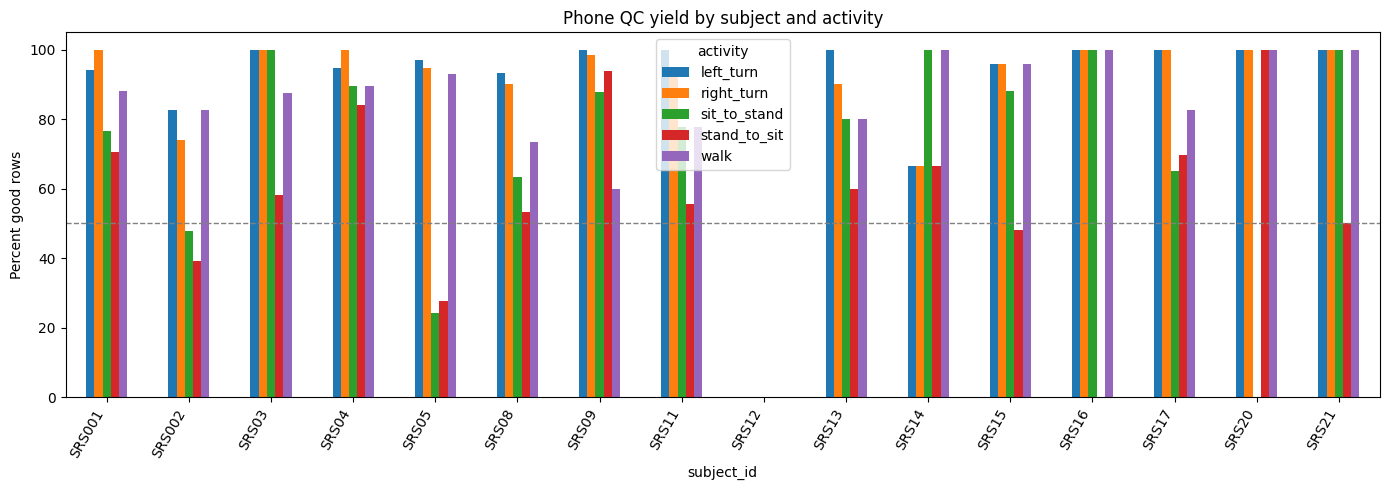

In [6]:
plot_qc_yield(qc_yield)

### Plot 2: Phone vs lab walking cadence

Cadence is a primary walking agreement metric because it is normalized by time and is less sensitive to different walking task durations.

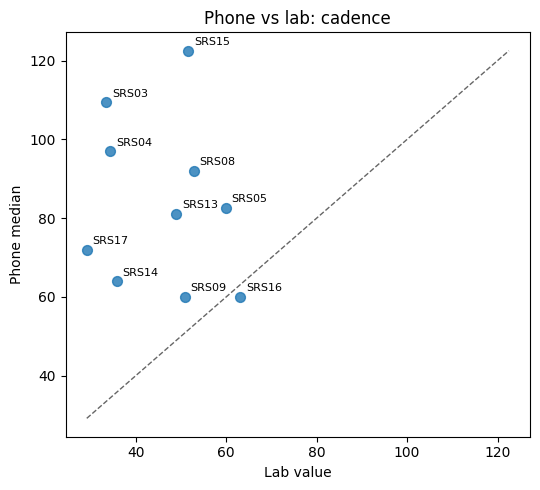

In [7]:
scatter_phone_lab(phone_lab_comparison, "cadence", "scatter_cadence.png")

### Plot 3: Phone vs lab mean step time

Mean step time should roughly mirror cadence. Large disagreement here may indicate sensor choice, lab task mismatch, or step timing extraction issues.

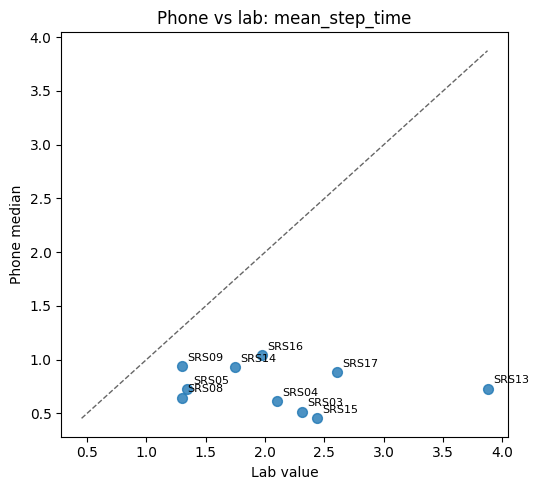

In [8]:
scatter_phone_lab(phone_lab_comparison, "mean_step_time", "scatter_mean_step_time.png")

### Plot 4: Phone vs lab left turn duration

Turn duration is clinically interpretable, but can be sensitive to segmentation boundaries.

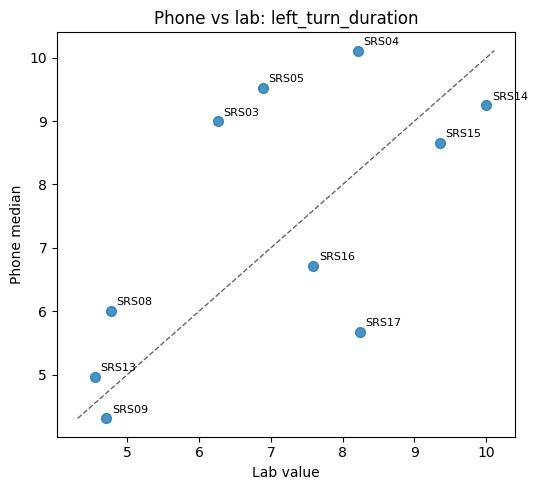

In [9]:
scatter_phone_lab(phone_lab_comparison, "left_turn_duration", "scatter_left_turn_duration.png")

### Plot 5: Phone vs lab right turn duration

Compare this with left turn duration to check whether one turn direction is more stable.

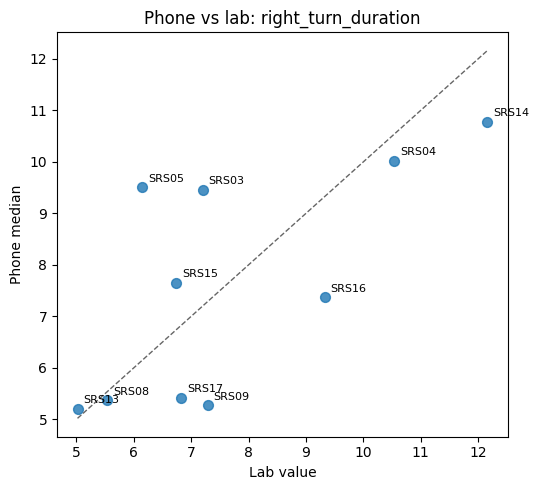

In [10]:
scatter_phone_lab(phone_lab_comparison, "right_turn_duration", "scatter_right_turn_duration.png")

### Plot 6: Phone vs lab left turn peak angular velocity

Peak angular velocity is a promising turning feature, but can be affected by sensor placement and filtering.

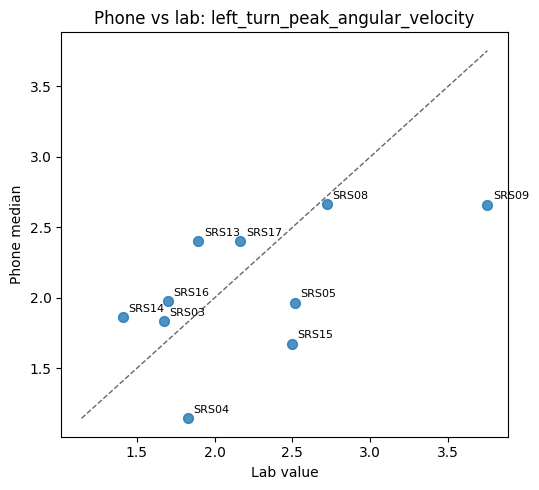

In [11]:
scatter_phone_lab(phone_lab_comparison, "left_turn_peak_angular_velocity", "scatter_left_turn_peak_angular_velocity.png")

### Plot 7: Phone vs lab right turn peak angular velocity

This feature currently ranks strongly if the patient-level scatter stays close to the identity line.

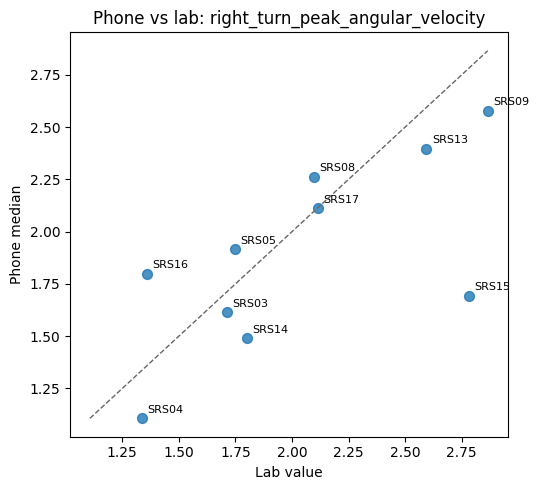

In [12]:
scatter_phone_lab(phone_lab_comparison, "right_turn_peak_angular_velocity", "scatter_right_turn_peak_angular_velocity.png")

### Plot 8: Bland-Altman for cadence

Use this to inspect systematic bias and limits of agreement, not just correlation.

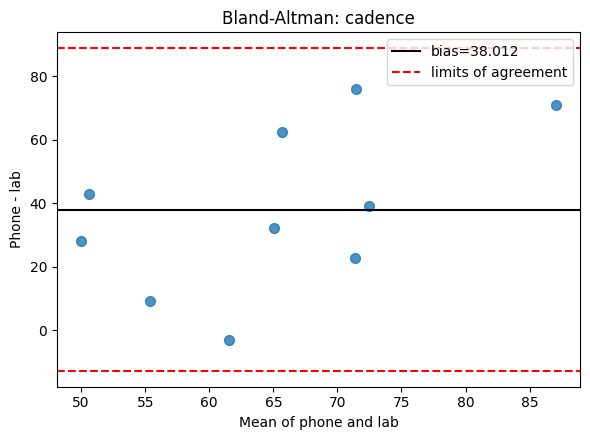

In [13]:
bland_altman_plot(phone_lab_comparison, "cadence", "bland_altman_cadence.png")

### Plot 9: Bland-Altman for right turn peak angular velocity

This checks whether the phone systematically over- or under-estimates the lab peak angular velocity.

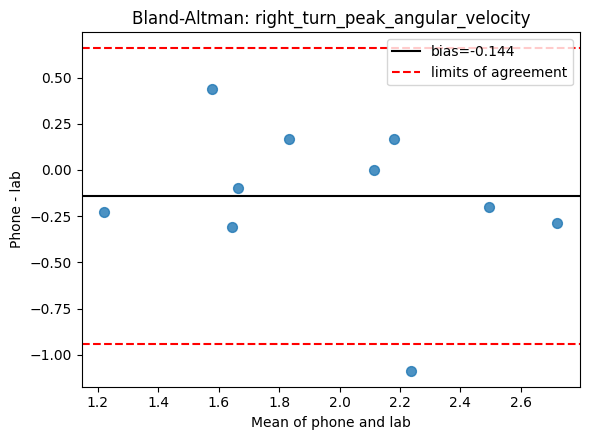

In [14]:
bland_altman_plot(phone_lab_comparison, "right_turn_peak_angular_velocity", "bland_altman_right_turn_peak_angular_velocity.png")

### Plot 10: Feature validation heatmap

Lower median percent error is better. Treat nonlinear and cross-correlation metrics as exploratory unless ranking metrics are consistently strong.

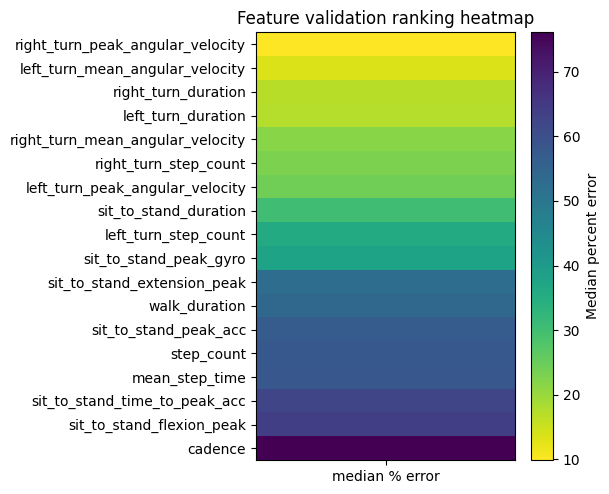

In [15]:
plot_validation_heatmap(feature_validation_ranking)

### Percent Error Table

This table shows feature-level median percent error after the heatmap. Lower values indicate closer patient-level agreement between phone median and lab median. Use this table to quickly see which features are most interpretable and which are noisy.

In [16]:

percent_error_table = feature_validation_ranking[
    [
        "feature",
        "validation_strength",
        "matched_n",
        "median_percent_error",
        "MAE",
        "RMSE",
        "spearman_correlation",
        "ICC_absolute_agreement",
    ]
].copy()
percent_error_table = percent_error_table.sort_values("median_percent_error", na_position="last").reset_index(drop=True)
percent_error_table.to_csv(OUTPUT_DIR / "feature_percent_error_summary.csv", index=False, float_format="%.3f")
display(percent_error_table)


,feature,validation_strength,matched_n,median_percent_error,MAE,RMSE,spearman_correlation,ICC_absolute_agreement
0,right_turn_peak_angular_velocity,strong,10,9.863,0.299,0.413,0.685,0.666
1,left_turn_mean_angular_velocity,strong,10,13.356,0.161,0.190,0.806,0.769
2,right_turn_duration,strong,10,17.094,1.415,1.711,0.600,0.701
3,left_turn_duration,moderate,10,17.305,1.419,1.681,0.539,0.654
4,right_turn_mean_angular_velocity,moderate,10,21.728,0.170,0.190,0.867,0.752
5,right_turn_step_count,moderate,10,23.044,4.100,4.930,0.308,0.418
6,left_turn_peak_angular_velocity,moderate,10,24.294,0.483,0.571,0.559,0.528
7,sit_to_stand_duration,moderate,10,30.127,0.813,1.087,0.164,0.135
8,left_turn_step_count,weak,10,35.608,4.500,5.074,0.279,0.222
9,sit_to_stand_peak_gyro,weak,10,37.677,0.708,0.865,0.164,0.088


## Final Data-Driven Summary

In [17]:
def print_final_summary(ranking):
    if ranking.empty:
        print("No matched phone-lab features were available. Check subjects.json and lab result CSVs.")
        return
    for label in ["strong", "moderate", "weak", "exploratory"]:
        subset = ranking.loc[ranking["validation_strength"] == label, "feature"].tolist()
        print(f"\n{label.upper()} FEATURES")
        print(", ".join(subset) if subset else "None identified with current thresholds/data.")
    print("\nInterpretation guardrails:")
    print("- Smartphone features are not all valid equally.")
    print("- Walking cadence and mean_step_time are likely strong candidates if they agree with lab.")
    print("- Turn mean/peak angular velocity and turn duration are promising when lab agreement is good.")
    print("- Turn step count may be biased by segmentation and should be interpreted cautiously.")
    print("- Sit-to-stand duration may be weak if the phone movement window is too broad.")
    print("- Entropy, Lyapunov, RQA, jerk, and cross-correlation features are exploratory unless they show reliability and agreement.")
    print("\nRecommended paper framing:")
    print('"Feature-level feasibility and validation of waist-worn smartphone IMU metrics for stroke mobility assessment using multi-sensor laboratory IMUs."')

print_final_summary(feature_validation_ranking)


STRONG FEATURES
right_turn_peak_angular_velocity, left_turn_mean_angular_velocity, right_turn_duration

MODERATE FEATURES
left_turn_duration, right_turn_mean_angular_velocity, right_turn_step_count, left_turn_peak_angular_velocity, sit_to_stand_duration

WEAK FEATURES
left_turn_step_count, sit_to_stand_peak_gyro, sit_to_stand_extension_peak, walk_duration, sit_to_stand_peak_acc, step_count, mean_step_time, sit_to_stand_time_to_peak_acc, sit_to_stand_flexion_peak, cadence

EXPLORATORY FEATURES
None identified with current thresholds/data.

Interpretation guardrails:
- Smartphone features are not all valid equally.
- Walking cadence and mean_step_time are likely strong candidates if they agree with lab.
- Turn mean/peak angular velocity and turn duration are promising when lab agreement is good.
- Turn step count may be biased by segmentation and should be interpreted cautiously.
- Sit-to-stand duration may be weak if the phone movement window is too broad.
- Entropy, Lyapunov, RQA, jer